In [1]:
from pathlib import Path

REPO_ROOT = Path().cwd().parent

OUT_ROOT = REPO_ROOT / "Topic_2" / "Output"

PLOT_ROOT = REPO_ROOT / "Topic_2" / "Plots"

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np

berlin = gpd.read_file(OUT_ROOT / "1_postcode_city_shapefiles" / "postcodes_berlin.shp")

index_wm = pd.read_csv(OUT_ROOT / "2_index_values" / "index_wm_long.csv")
index_wk = pd.read_csv(OUT_ROOT / "2_index_values" / "index_wk_long.csv")
index_hk = pd.read_csv(OUT_ROOT / "2_index_values" / "index_hk_long.csv")


In [3]:
berlin_grid = gpd.read_file(OUT_ROOT / "3_cbd" / "grid_11" / "grid_11.shp")

# Replace 0s with NaN in the employment share column
berlin_grid["emp_sh"] = berlin_grid["emp_sh"].replace(0, np.nan)

In [4]:
berlin_grid['emp_sh'].describe()

count    259.000000
mean       0.003861
std        0.003288
min        0.001473
25%        0.001473
50%        0.002946
75%        0.004081
max        0.022143
Name: emp_sh, dtype: float64

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_56645/3296544780.py:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gpd.GeoSeries([berlin.unary_union]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)


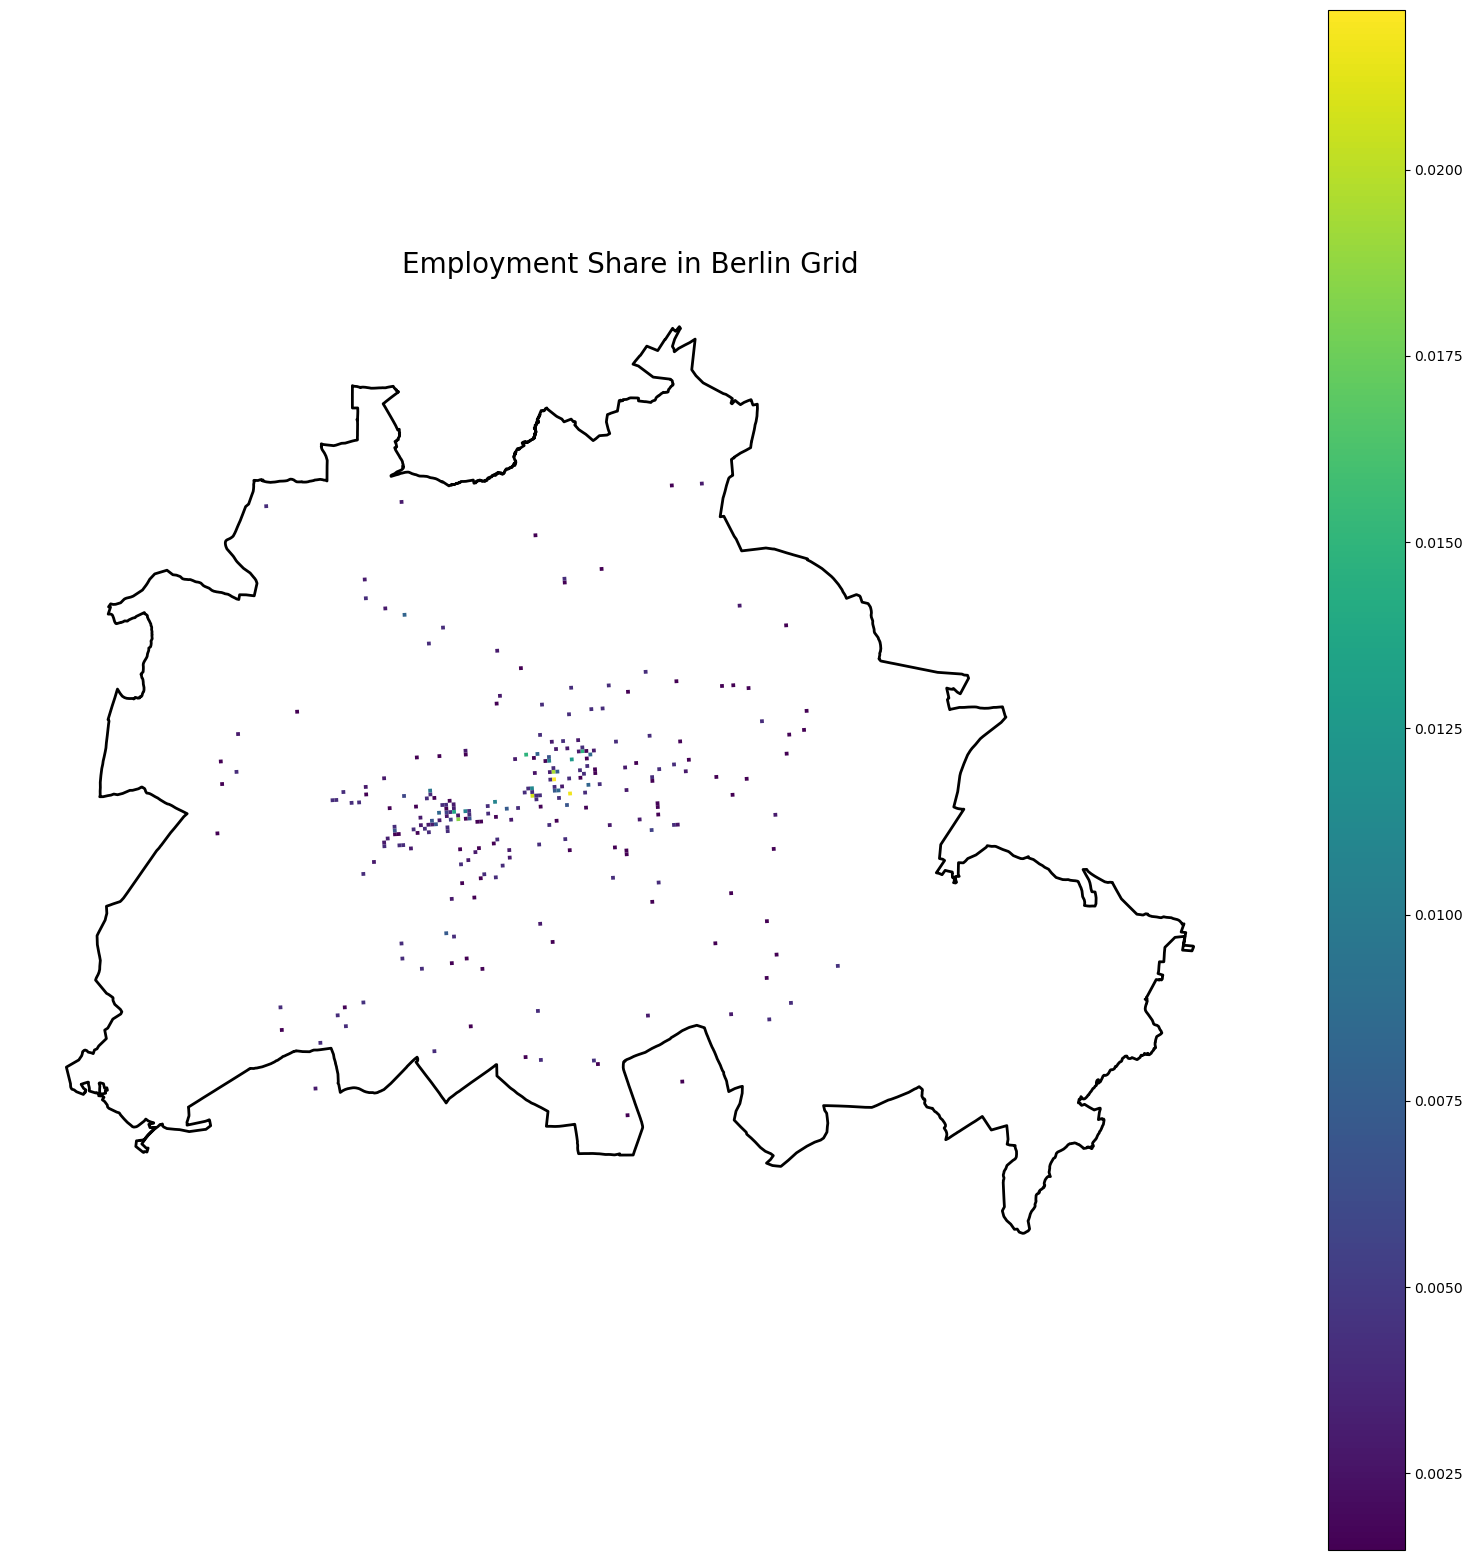

In [ ]:
# Plot the employment share column and the border of berlin
import matplotlib.pyplot as plt

choose_top_proc = 0.01
threshold = berlin_grid['emp_sh'].quantile(1 - choose_top_proc)
top_grid = berlin_grid[berlin_grid['emp_sh'] >= threshold]

fig, ax = plt.subplots(figsize=(20, 20))

top_grid.to_crs("EPSG:25832").plot(column="emp_sh", ax=ax, legend=True, cmap="viridis", markersize=1)
gpd.GeoSeries([berlin.unary_union]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
ax.set_title("Employment Share in Berlin Grid", fontsize=20)
ax.set_axis_off()
plt.show()